# 08 - Offline 3DVar reconstruction (imperfect-model PPE)

3DVar in the gain (dual) form, assimilating in anomaly space. The analysis is

    x_a = x_b + B H^T (H B H^T + R)^-1 (y - H x_b)

with H nearest-cell selection and R = diag(sse) + diag(c*rep_var): the proxy
transfer-function error plus a per-channel representativeness term. The only inverse
is the m x m matrix over one age's observations. Four background-covariance variants
are compared (raw sample B, EOF truncation, diagonal shrinkage, Gaspari-Cohn
localization), all built from the full LOVECLIM prior.

Two evaluation lanes:
- Imperfect-model PPE: truths are CCSM4 210 ppm fields (Vettoretti 2022) regridded to
  the LOVECLIM grid and anomalised by their own climatology, so the prior must
  reconstruct an out-of-distribution climate it was not built from. A single
  climatological background is used; pseudo-observations borrow a real proxy
  network's geometry and noise, with values from the CCSM4 truth.
- Real-proxy withholding (LMR-style Monte Carlo): predict withheld pollen sites.

The PPE sweeps an observation-noise multiplier k (each pseudo-observation is
H(x_true) + k*(e + w), e ~ N(0, sse), w ~ N(0, c*rep_var), R fixed; k=1 is
well-specified) and a B-vs-R amplitude b_scale (scales B before each analysis). The
headline tables fix b_scale = 1; dedicated sweep sections read across it.

Heavy compute lives in paleoreco.assim.experiments; this notebook runs the matrix
once, caches artifacts, and renders from them.

In [18]:
%load_ext autoreload
%autoreload 2

import glob
import os
import shutil
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))

from paleoreco.data import build_prior_cube, VARS
from paleoreco.data.equilibrium import load_equilibrium_run, truth_cube_on_grid
from paleoreco.assim.observations import (
    attach_site_stats, collapse_to_samples, load_observations, observation_site_stats,
)
from paleoreco.assim.innovation import nearest_lat_index, nearest_lon_index
from paleoreco.assim import experiments as ex
from paleoreco.eval import da

plt.rcParams["figure.dpi"] = 110
DATA = "../data"
OUT = Path("../outputs/da")
FIG = Path("../outputs/figures/08_3dvar")
FIG.mkdir(parents=True, exist_ok=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Prior cube, CCSM4 truths, and observation network

B and the climatology use the full LOVECLIM prior (every age, no holdout, since the
PPE truths are CCSM4 rather than LOVECLIM states). The CCSM4 210 ppm run is regridded
to the LOVECLIM grid and reduced to MTCO/MTWA truth fields (first 100 decades
trimmed, stride 25). The withholding lane assimilates real proxies in anomaly space
(y minus per-site climatology), so it needs the site statistics, estimated on the
collapsed (one-row-per-sample) table.

In [2]:
P = build_prior_cube(prior_csv=f"{DATA}/Prior.csv", cache_path=f"{DATA}/cache/prior_cube.npz")
cube, ages, lats, lons, valid = P["cube"], P["ages"], P["lats"], P["lons"], P["valid"]

long_ppe = load_observations(f"{DATA}/Observation.csv")
long_wh = attach_site_stats(long_ppe, observation_site_stats(collapse_to_samples(long_ppe)))

run = load_equilibrium_run(f"{DATA}/cesmi6gat31rblc210_surfacetemp.npz")
truth_cube = truth_cube_on_grid(run, lats, lons)        # (n, 2, 32, 64) CCSM4 MTCO/MTWA degC
print(f"cube {cube.shape}, {len(ages)} ages, {long_ppe['site'].nunique()} sites; "
      f"CCSM4 truths {truth_cube.shape}")

cube (804, 2, 32, 64), 804 ages, 187 sites; CCSM4 truths (28, 2, 32, 64)


## Run the variant matrix

The four B variants are run here. For each, the imperfect-model PPE
(run_ppe_imperfect, climatological background) and the two real-proxy k-fold
withholding lanes write their metrics, analysis fields, and config under the
variant's directory. Re-running clears the directory first so the appended metrics
CSV stays clean.

In [3]:
VARIANTS = {
    "raw": {},
    "eof": {"eof_rank": 11},
    "shrinkage": {"shrinkage_lambda": 0.25},
    "localization": {"localization_km": 5000.0},
}
REP_LEVELS = (1.0, 1.5, 2.0, 2.5, 3.0)
C_REP = (0.06, 0.18)                                # per-channel rep scale (mtco, mtwa)
B_SCALES = (0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0)

for name, kw in VARIANTS.items():
    d = OUT / f"3dvar_{name}"
    if d.exists():
        shutil.rmtree(d)
    ex.run_ppe_imperfect(truth_cube, cube, ages, lats, lons, valid, long_ppe, str(d),
                         b_reg=name, rep_levels=REP_LEVELS, c_rep=C_REP, b_scales=B_SCALES, **kw)
    ex.run_withholding(cube, ages, lats, lons, valid, long_wh, str(d),
                       b_reg=name, fold_kind="random", c_rep=C_REP, b_scales=B_SCALES, **kw)
    ex.run_withholding(cube, ages, lats, lons, valid, long_wh, str(d),
                       b_reg=name, fold_kind="spatial", c_rep=C_REP, b_scales=B_SCALES, **kw)
    print("done", name)

done raw
done eof
done shrinkage
done localization


## Headline skill table

CE (pooled channels) per lane, background, and B variant, at b_scale = 1. The PPE
lane (lane="ppe_imperfect") scores CCSM4 truths; its naive baselines (nearest-obs,
inverse-distance) sit under method != 3dvar.

In [4]:
M = pd.concat([pd.read_csv(p) for p in glob.glob(str(OUT / "3dvar_*/metrics.csv"))],
              ignore_index=True)

# Headline table fixes b_scale=1; the B-vs-R sweep is read in its own section.
pooled = M[(M.channel == "pooled") & (M.do_event == "all") & (M.metric == "ce")
           & (M.b_scale == 1.0)]
table = pooled[pooled.method == "3dvar"].pivot_table(
    index=["lane", "background", "rep_K"], columns="B_reg", values="value")
display(table.round(3))

naive = pooled[pooled.method != "3dvar"][["method", "rep_K", "value"]].drop_duplicates()
print("PPE naive-baseline CE by rep_K:")
display(naive.pivot_table(index="rep_K", columns="method", values="value").round(3))

B_reg                                       eof  localization    raw  \
lane                background     rep_K                               
ppe_imperfect       climatological 1.0    0.065         0.020  0.084   
                                   1.5   -0.047        -0.092 -0.025   
                                   2.0   -0.194        -0.238 -0.168   
                                   2.5   -0.375        -0.417 -0.345   
                                   3.0   -0.591        -0.629 -0.556   
withholding_random  climatological 0.0    0.057         0.058  0.061   
                    per_age        0.0    0.047         0.048  0.052   
withholding_spatial climatological 0.0    0.054         0.001  0.055   
                    per_age        0.0    0.054         0.018  0.055   

B_reg                                     shrinkage  
lane                background     rep_K             
ppe_imperfect       climatological 1.0        0.075  
                                   1.5       -0.018  
                                   2.0       -0.138  
                                   2.5       -0.287  
                                   3.0       -0.464  
withholding_random  climatological 0.0        0.067  
                    per_age        0.0        0.055  
withholding_spatial climatological 0.0        0.057  
                    per_age        0.0        0.055

PPE naive-baseline CE by rep_K:


method,idw,nearest
rep_K,,
1.0,0.303,-0.794
1.5,0.147,-2.326
2.0,-0.070,-4.469
2.5,-0.347,-7.224
3.0,-0.686,-10.592


## SSIM and RRMSE

Two more skill axes from the same metrics.csv. RRMSE is RMSE normalised by the
truth std, so it is comparable across channels and lanes; SSIM scores spatial
structure and exists only in the PPE lane, where a gridded model truth is held
out (the withholding lanes score scattered proxy points, with no field to compare
against). Both pooled over channels and all ages.

In [5]:
pooled = M[(M.method == "3dvar") & (M.channel == "pooled") & (M.do_event == "all")
           & (M.b_scale == 1.0)]

for metric in ("ssim", "rrmse"):
    sub = pooled[(pooled.lane == "ppe_imperfect") & (pooled.metric == metric)]
    if len(sub):
        print(f"PPE {metric.upper()} (pooled channels):")
        display(sub.pivot_table(index=["background", "rep_K"], columns="B_reg",
                                values="value").round(3))

# MC RRMSE appears once the Monte Carlo cell below has run (no SSIM there: obs space).
mc = pooled[(pooled.lane == "withholding_montecarlo") & (pooled.metric == "rrmse")
            & (pooled.fold == -1)]
if len(mc):
    print("LMR-MC ensemble-mean RRMSE (pooled):")
    display(mc.pivot_table(index="background", columns="B_reg", values="value").round(3))

PPE SSIM (pooled channels):


B_reg                   eof  localization    raw  shrinkage
background     rep_K                                       
climatological 1.0    0.316         0.355  0.320      0.311
               1.5    0.302         0.327  0.307      0.301
               2.0    0.287         0.302  0.292      0.289
               2.5    0.271         0.280  0.276      0.275
               3.0    0.255         0.261  0.260      0.262

PPE RRMSE (pooled channels):


B_reg                   eof  localization    raw  shrinkage
background     rep_K                                       
climatological 1.0    0.967         0.990  0.957      0.962
               1.5    1.023         1.045  1.012      1.009
               2.0    1.093         1.112  1.081      1.067
               2.5    1.173         1.190  1.160      1.134
               3.0    1.262         1.276  1.247      1.210

## PPE skill maps

Per-cell CE across the CCSM4 truths shows where the reconstruction has skill. Cells
off the valid mask are blanked.

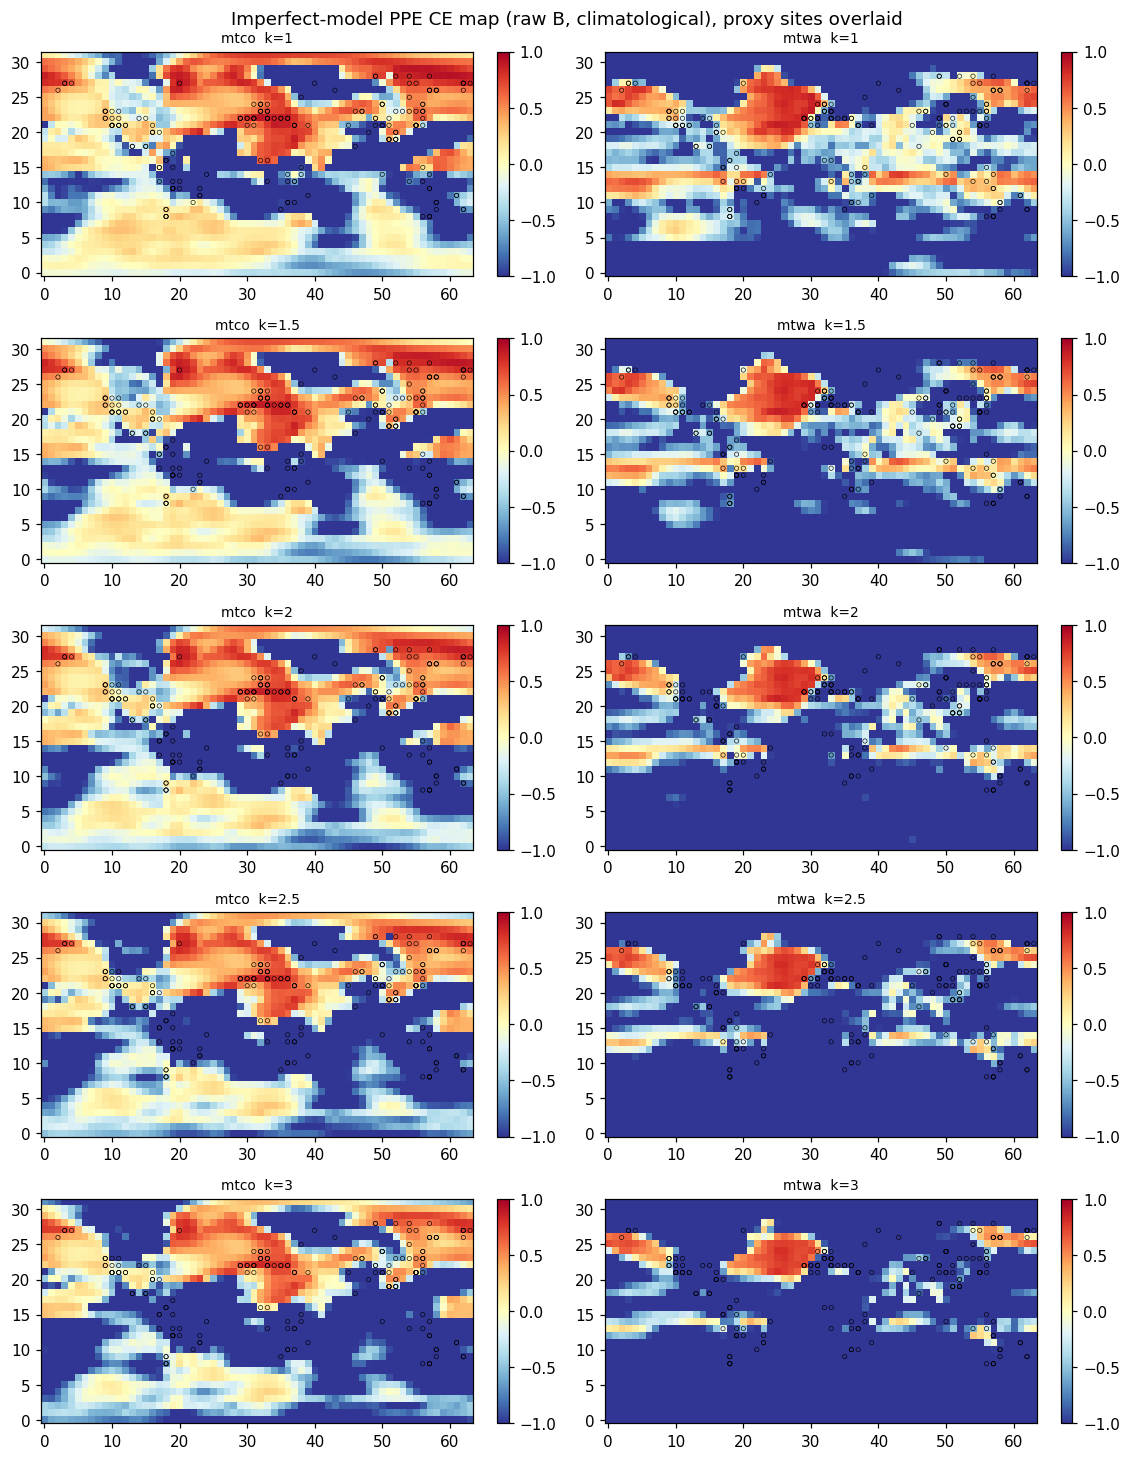

In [ ]:

z = np.load(OUT / "3dvar_raw" / "ppe_imperfect_analysis.npz")
truth, sv = z["truth_anom"], z["safe_valid"]
reps = z["rep_levels"]
b_scales = z["b_scales"]
bi1 = int(np.argmin(np.abs(b_scales - 1.0)))         # the b_scale=1 slice for the maps
ref0 = np.zeros_like(truth[0])
recon = z["recon_climatological"][:, bi1]            # (n_K, T, 2, n_lat, n_lon) at b_scale=1

sites = long_ppe.drop_duplicates("site")             # proxy-pool footprint (sites vary per truth)
si = nearest_lat_index(sites["lat"].to_numpy(), lats)
sj = nearest_lon_index(sites["lon"].to_numpy(), lons)

fig, axes = plt.subplots(len(reps), len(VARS),
                         figsize=(5.2 * len(VARS), 2.7 * len(reps)), squeeze=False)
for ki, k in enumerate(reps):
    cem = da.ce_map(truth, recon[ki], ref0)
    cem = np.where(np.broadcast_to(sv, cem.shape), cem, np.nan)
    for c in range(len(VARS)):
        ax = axes[ki, c]
        im = ax.imshow(cem[c], origin="lower", cmap="BrBG", vmin=-1.0, vmax=1.0, aspect="auto")
        ax.scatter(sj, si, s=8, facecolors="none", edgecolors="red", linewidths=0.4)
        ax.set_title(f"{VARS[c]}  k={k:g}", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Imperfect-model PPE CE map (raw B, climatological), proxy sites overlaid")
fig.tight_layout()
fig.savefig(str(FIG / "ce_map_raw_climatological.png"), dpi=110, bbox_inches="tight")
plt.show()


## Skill vs distance to nearest observation

How fast skill decays into data voids. A prior that holds skill further from the
proxies decays more slowly; this is the axis the regularizer choice and, later,
the generative prior most affect. One panel per B variant, one line per
representativeness level K: at K=0 every variant holds skill into the voids; the
question is whether localization decays more gracefully than raw as K grows.

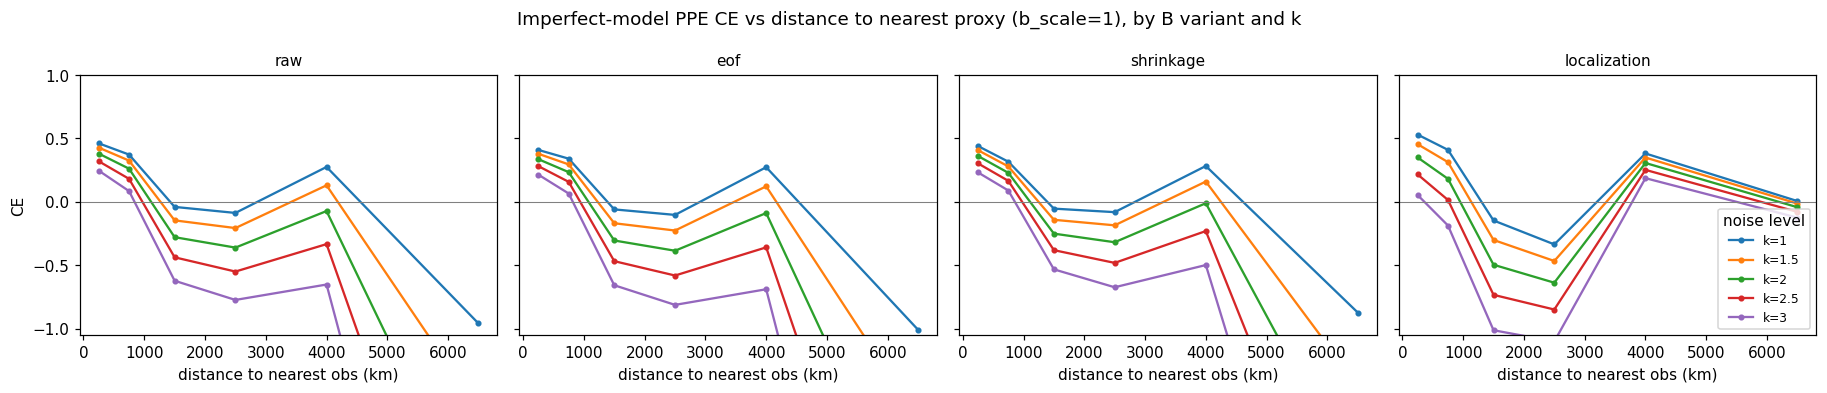

In [7]:
fig, axes = plt.subplots(1, len(VARIANTS), figsize=(4.2 * len(VARIANTS), 3.6),
                         sharey=True, squeeze=False)
for ax, name in zip(axes[0], VARIANTS):
    s = np.load(OUT / f"3dvar_{name}" / "ppe_imperfect_skill_vs_distance.npz")
    centres = 0.5 * (s["edges"][:-1] + s["edges"][1:])
    bi1 = int(np.argmin(np.abs(s["b_scales"] - 1.0)))
    for ki, k in enumerate(s["rep_levels"]):
        ax.plot(centres, s["climatological"][ki, bi1], marker="o", ms=3, label=f"k={k:g}")
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_ylim(-1.05, 1.0)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("distance to nearest obs (km)")
axes[0, 0].set_ylabel("CE")
axes[0, -1].legend(fontsize=8, title="noise level")
fig.suptitle("Imperfect-model PPE CE vs distance to nearest proxy (b_scale=1), by B variant and k")
fig.tight_layout()
fig.savefig(str(FIG / "skill_vs_distance.png"), dpi=110, bbox_inches="tight")
plt.show()

## PPE prior vs posterior error

What assimilation buys against the held-out CCSM4 truth, raw B at b_scale 1 and the
lowest noise level k=1 (there is no noise-free level here). The realized error
reduction is the per-cell drop in RMSE from the climatological first guess to the
analysis: 1 where the analysis removes all background error, 0 where it does nothing,
negative where it hurts. The claimed uncertainty reduction is diag A against diag B.
The reliability map divides the realized analysis RMSE by the predicted posterior
std: near 1 the error bars are honest, above 1 overconfident.

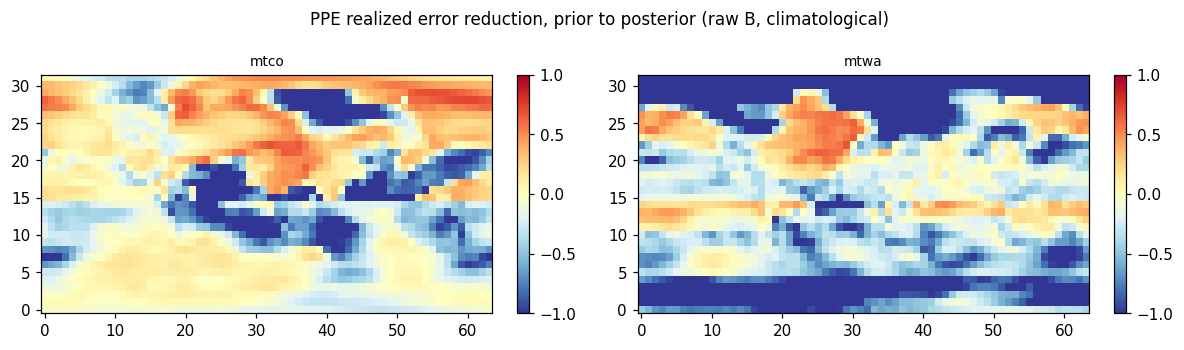

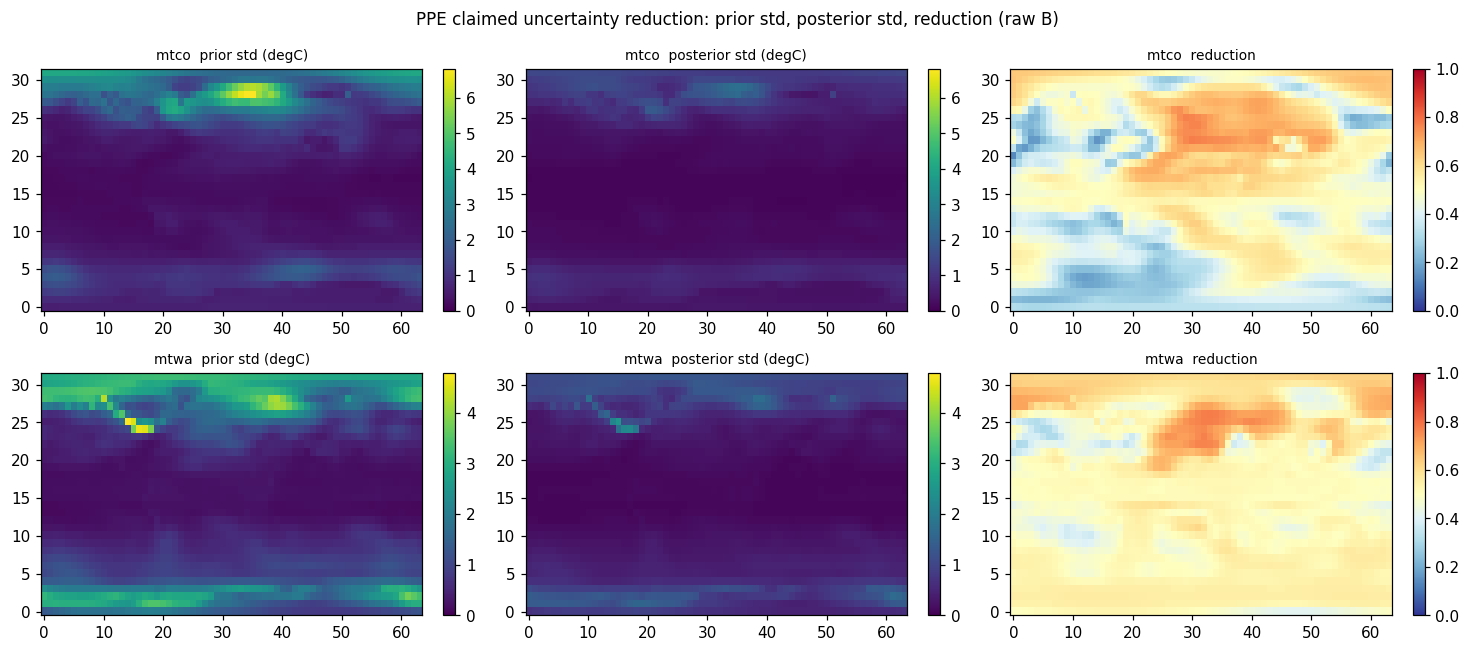

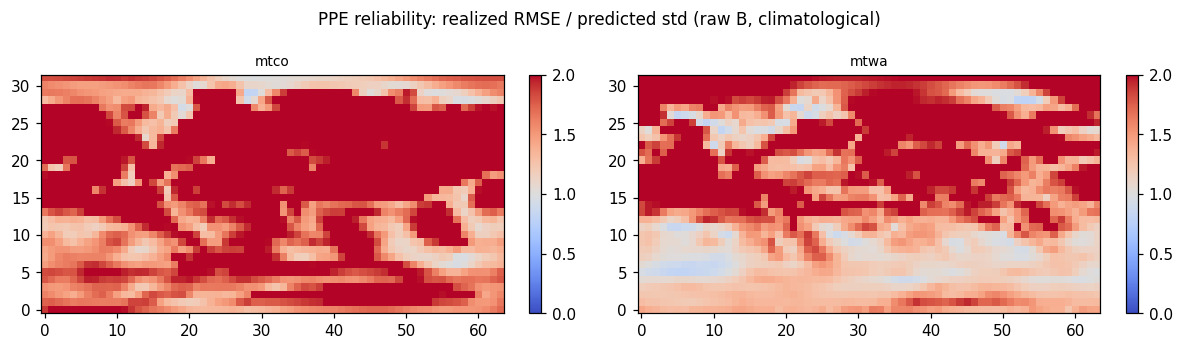

In [8]:
# Prior vs posterior error, PPE lane (CCSM4 truth, raw B, b_scale=1, lowest k).
k0 = int(np.argmin(reps))                            # lowest noise level (k=1 here)
post_var_mean = z["post_var"][bi1].mean(axis=0)

red = da.error_reduction_map(truth, np.zeros_like(truth), z["recon_climatological"][k0, bi1])
red = np.where(np.broadcast_to(sv, red.shape), red, np.nan)
da.plot_skill_map(red, VARS, vmin=-1.0, vmax=1.0,
                  title="PPE realized error reduction, prior to posterior (raw B, climatological)",
                  save_path=str(FIG / "error_reduction_raw_climatological.png"))
plt.show()

da.plot_prior_posterior_uncertainty(
    z["prior_var"], post_var_mean, sv, VARS,
    title="PPE claimed uncertainty reduction: prior std, posterior std, reduction (raw B)",
    save_path=str(FIG / "uncertainty_reduction_ppe_raw.png"))
plt.show()

# Reliability: realized analysis RMSE over the predicted posterior std, 1 = honest.
realized = da.rmse_map(truth, z["recon_climatological"][k0, bi1])
reliab = np.where(np.broadcast_to(sv, realized.shape), realized / np.sqrt(post_var_mean), np.nan)
da.plot_skill_map(reliab, VARS, cmap="coolwarm", vmin=0.0, vmax=2.0,
                  title="PPE reliability: realized RMSE / predicted std (raw B, climatological)",
                  save_path=str(FIG / "reliability_ppe_raw.png"))
plt.show()

## Uncertainty

RCRV bias and dispersion (calibrated near 0 and 1), per B variant and noise level k,
at b_scale = 1. R does not depend on k, so the posterior variance is fixed along this
axis. Dispersion well above 1 here reflects the prior being mis-scaled for
out-of-distribution CCSM4 truths; the b_scale sweep below is the knob for it.

In [9]:
rc = M[(M.metric.isin(["rcrv_bias", "rcrv_disp"])) & (M.lane == "ppe_imperfect") & (M.b_scale == 1.0)]
display(rc.pivot_table(index=["B_reg", "background", "rep_K"], columns="metric", values="value").round(3))

metric                             rcrv_bias  rcrv_disp
B_reg        background     rep_K                      
eof          climatological 1.0       -0.020      3.901
                            1.5       -0.019      3.997
                            2.0       -0.017      4.130
                            2.5       -0.015      4.296
                            3.0       -0.014      4.492
localization climatological 1.0       -0.038      1.754
                            1.5       -0.047      1.803
                            2.0       -0.056      1.868
                            2.5       -0.065      1.948
                            3.0       -0.073      2.041
raw          climatological 1.0       -0.026      2.997
                            1.5       -0.027      3.090
                            2.0       -0.028      3.217
                            2.5       -0.030      3.373
                            3.0       -0.031      3.555
shrinkage    climatological 1.0       -0.013      2.072
                            1.5       -0.013      2.123
                            2.0       -0.013      2.195
                            2.5       -0.013      2.285
                            3.0       -0.013      2.391

## B vs R amplitude sweep

Skill and calibration as B is scaled by b_scale with R fixed, at the lowest noise
level k=1. Raising b_scale trusts the observations more: with an out-of-distribution
prior, more obs weight tends to lift CE and pull the dispersion down toward 1.

PPE ce vs b_scale (k=1), by B variant:


B_reg                     eof  localization    raw  shrinkage
background     b_scale                                       
climatological 0.50     0.058         0.141  0.070      0.079
               0.75     0.059         0.077  0.075      0.073
               1.00     0.065         0.020  0.084      0.075
               1.25     0.072        -0.032  0.095      0.079
               1.50     0.079        -0.079  0.104      0.085
               1.75     0.084        -0.122  0.113      0.090
               2.00     0.088        -0.161  0.120      0.096

PPE rcrv_disp vs b_scale (k=1), by B variant:


B_reg                     eof  localization    raw  shrinkage
background     b_scale                                       
climatological 0.50     4.579         2.369  3.726      2.817
               0.75     4.159         1.983  3.281      2.357
               1.00     3.901         1.754  2.997      2.072
               1.25     3.722         1.597  2.792      1.872
               1.50     3.587         1.482  2.634      1.722
               1.75     3.482         1.393  2.506      1.604
               2.00     3.396         1.321  2.401      1.508

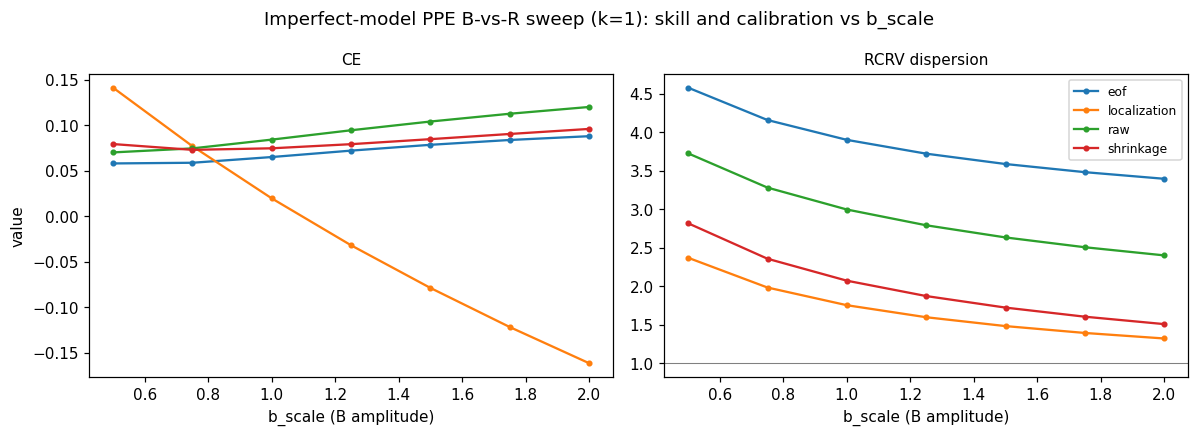

In [10]:
sweep = M[(M.lane == "ppe_imperfect") & (M.method == "3dvar") & (M.channel == "pooled")
          & (M.do_event == "all") & (M.rep_K == 1.0)]
for metric in ("ce", "rcrv_disp"):
    sub = sweep[sweep.metric == metric]
    print(f"PPE {metric} vs b_scale (k=1), by B variant:")
    display(sub.pivot_table(index=["background", "b_scale"], columns="B_reg",
                            values="value").round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4), squeeze=False)
for ax, metric, lab in zip(axes[0], ("ce", "rcrv_disp"), ("CE", "RCRV dispersion")):
    sub = sweep[sweep.metric == metric]
    for name, g in sub.groupby("B_reg"):
        g = g.sort_values("b_scale")
        ax.plot(g.b_scale, g.value, marker="o", ms=3, label=name)
    ax.set_xlabel("b_scale (B amplitude)")
    ax.set_title(lab, fontsize=10)
    if metric == "rcrv_disp":
        ax.axhline(1.0, color="grey", lw=0.7)
axes[0, 0].set_ylabel("value")
axes[0, 1].legend(fontsize=8)
fig.suptitle("Imperfect-model PPE B-vs-R sweep (k=1): skill and calibration vs b_scale")
fig.tight_layout()
fig.savefig(str(FIG / "b_scale_sweep_ppe.png"), dpi=110, bbox_inches="tight")
plt.show()

## Reading

- The headline is CE of a LOVECLIM-built covariance against out-of-distribution CCSM4
  truths. Expect it far below the perfect-model PPE in 08_3dvar: that gap is the
  in-distribution flattery this experiment removes.
- Read localization/EOF/shrinkage against raw: a prior that generalises better to a
  different model's variability decays more gracefully into the data voids.
- skill-vs-distance: the decay rate into voids is the sparse-reconstruction signal.
- RCRV dispersion above 1 is overconfident; here it largely reflects the prior being
  mis-scaled for OOD truths, which the b_scale sweep is the knob for.
- noise (k) sweep: k=1 is the well-specified twin; k>1 inflates obs error beyond what
  R models, so CE falls and dispersion rises.
- b_scale sweep: the largest b_scale that keeps dispersion near 1 is the calibrated
  observation weight for this out-of-distribution setting.

## LMR-style Monte Carlo ensemble (75/25 resampling)

With B learned once, assimilate a random 75% of the proxy sites and withhold the
rest, repeated over many independent draws (Hakim et al. 2016). Whole sites move
together, so a site's every age and both channels are assimilated or withheld as a
unit. The deterministic 3DVar reconstructions form a resampling ensemble whose
spread measures sensitivity to which proxies were used.

No observation jitter is added: the square-root filter LMR uses avoids perturbing
observations, and the proxy error enters the calibration variance analytically
(total predictive variance = resampling spread + posterior variance + sse +
c*rep_var) rather than as injected noise.

Three products from one run: the per-realization skill distribution at withheld
sites, the ensemble-mean reconstruction with its across-realization spread, and a
proxy-space calibration check. Each is produced across the b_scale sweep; the maps
and tables below fix b_scale = 1. Results append to the same metrics.csv schema
under each B variant's directory, alongside the k-fold withholding rows.

In [11]:
N_REAL = 100

for name, kw in VARIANTS.items():
    d = OUT / f"3dvar_{name}"
    mpath = d / "metrics.csv"
    if mpath.exists():                                   # idempotent: drop prior MC rows
        m = pd.read_csv(mpath)
        m[m.lane != "withholding_montecarlo"].to_csv(mpath, index=False)
    for f in d.glob("montecarlo_*"):
        f.unlink()
    print(name)
    ex.run_montecarlo_withholding(cube, ages, lats, lons, valid, long_wh, str(d),
                                  b_reg=name, n_realizations=N_REAL, seed=0,
                                  c_rep=C_REP, b_scales=B_SCALES,
                                  progress_every=20, **kw)
    print("done", name)

raw
  realization 20/100
  realization 40/100
  realization 60/100
  realization 80/100
  realization 100/100
done raw
eof
  realization 20/100
  realization 40/100
  realization 60/100
  realization 80/100
  realization 100/100
done eof
shrinkage
  realization 20/100
  realization 40/100
  realization 60/100
  realization 80/100
  realization 100/100
done shrinkage
localization
  realization 20/100
  realization 40/100
  realization 60/100
  realization 80/100
  realization 100/100
done localization


### Skill distribution vs k-fold

Per-realization CE at the withheld sites (box) against the single pooled k-fold
withholding CE (red). The box is the spread the k-fold number cannot show: how
much the score depends on which quarter of the network was held out.

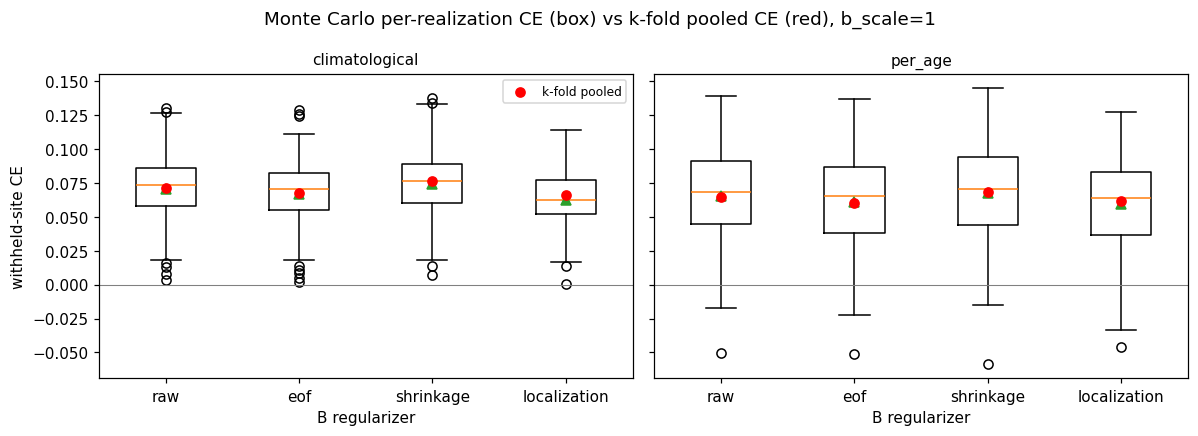

In [12]:
M = pd.concat([pd.read_csv(p) for p in glob.glob(str(OUT / "3dvar_*/metrics.csv"))],
              ignore_index=True)
mc = M[(M.lane == "withholding_montecarlo") & (M.channel == "pooled") & (M.metric == "ce")
       & (M.b_scale == 1.0)]
kf = M[(M.lane == "withholding_random") & (M.channel == "pooled") & (M.metric == "ce")
       & (M.fold == -1) & (M.b_scale == 1.0)]

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, squeeze=False)
for ax, bg in zip(axes[0], ("climatological", "per_age")):
    data = [mc[(mc.B_reg == name) & (mc.background == bg) & (mc.fold >= 0)].value.to_numpy()
            for name in VARIANTS]
    ax.boxplot(data, tick_labels=list(VARIANTS), showmeans=True)
    for i, name in enumerate(VARIANTS, start=1):
        k = kf[(kf.B_reg == name) & (kf.background == bg)].value
        if len(k):
            ax.scatter([i], [k.iloc[0]], color="red", zorder=3,
                       label="k-fold pooled" if i == 1 else None)
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_title(bg, fontsize=10)
    ax.set_xlabel("B regularizer")
axes[0, 0].set_ylabel("withheld-site CE")
axes[0, 0].legend(fontsize=8)
fig.suptitle("Monte Carlo per-realization CE (box) vs k-fold pooled CE (red), b_scale=1")
fig.tight_layout()
fig.savefig(str(FIG / "montecarlo_skill_distribution.png"), dpi=110, bbox_inches="tight")
plt.show()

### B vs R amplitude sweep (withheld sites)

Ensemble-mean CE at withheld proxies across b_scale, per B variant and background.
The real-proxy analogue of the PPE sweep: where the PPE measures skill against
model truth, this measures it against held-out pollen, so the b_scale that peaks
here is the one the operational reconstruction should use.

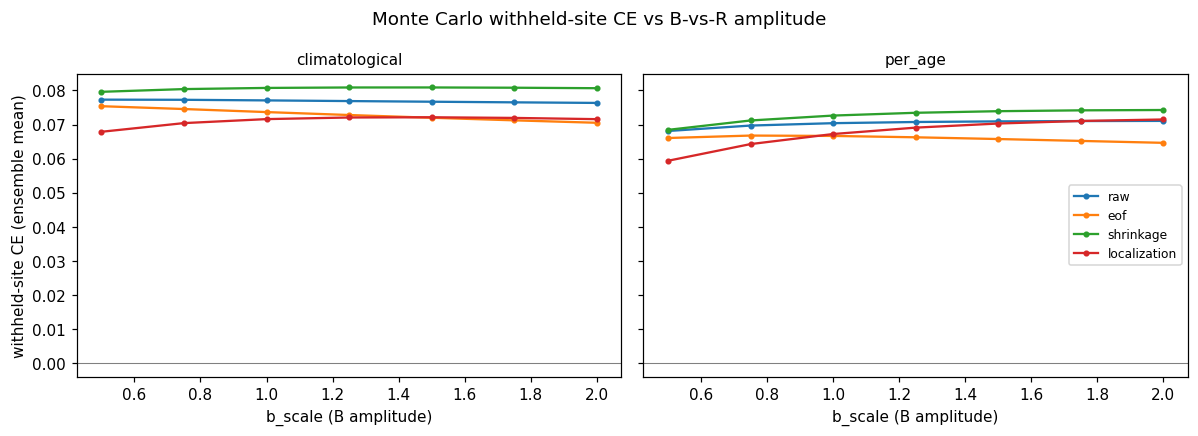

In [13]:
mcb = M[(M.lane == "withholding_montecarlo") & (M.channel == "pooled")
        & (M.metric == "ce") & (M.fold == -1)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True, squeeze=False)
for ax, bg in zip(axes[0], ("climatological", "per_age")):
    for name in VARIANTS:
        g = mcb[(mcb.B_reg == name) & (mcb.background == bg)].sort_values("b_scale")
        ax.plot(g.b_scale, g.value, marker="o", ms=3, label=name)
    ax.axhline(0, color="grey", lw=0.7)
    ax.set_title(bg, fontsize=10)
    ax.set_xlabel("b_scale (B amplitude)")
axes[0, 0].set_ylabel("withheld-site CE (ensemble mean)")
axes[0, -1].legend(fontsize=8)
fig.suptitle("Monte Carlo withheld-site CE vs B-vs-R amplitude")
fig.tight_layout()
fig.savefig(str(FIG / "b_scale_sweep_montecarlo.png"), dpi=110, bbox_inches="tight")
plt.show()

### Ensemble-mean reconstruction and spread

The ensemble-mean reconstruction at one age and its across-realization spread: the
resampling uncertainty, showing where the network constrains the field.

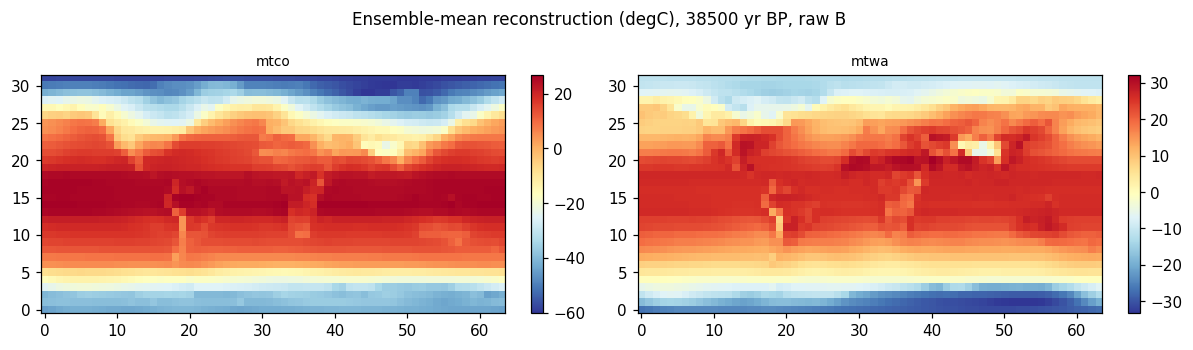

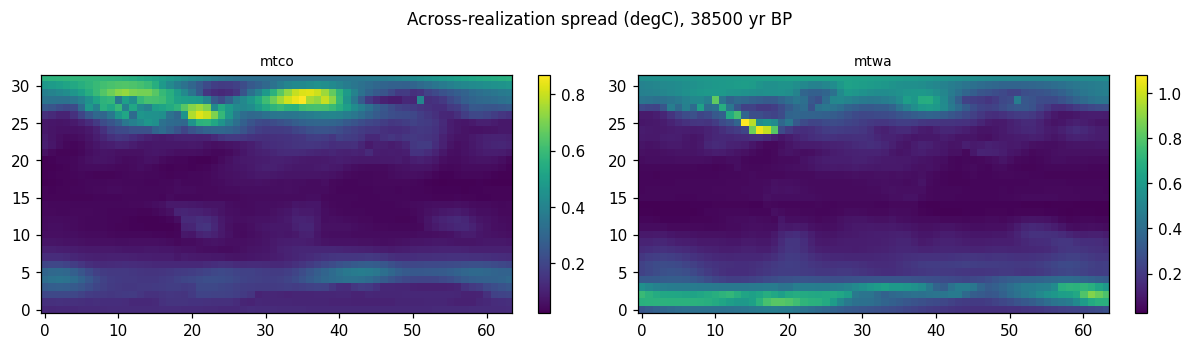

In [14]:
z = np.load(OUT / "3dvar_raw" / "montecarlo_ensemble.npz")
obs_ages, sv, clim = z["obs_ages"], z["safe_valid"], z["clim_mean"]
bi1 = int(np.argmin(np.abs(z["b_scales"] - 1.0)))
ai = int(np.abs(obs_ages - 38500).argmin())              # a representative MIS-3 age
mask = np.broadcast_to(sv, clim.shape)

recon = np.where(mask, z["recon_mean_climatological"][bi1, ai] + clim, np.nan)
spread = np.where(mask, z["recon_std_climatological"][bi1, ai], np.nan)

da.plot_skill_map(recon, VARS, cmap="RdYlBu_r",
                  title=f"Ensemble-mean reconstruction (degC), {int(obs_ages[ai])} yr BP, raw B",
                  save_path=str(FIG / "montecarlo_recon_mean.png"))
plt.show()
da.plot_skill_map(spread, VARS, cmap="viridis",
                  title=f"Across-realization spread (degC), {int(obs_ages[ai])} yr BP",
                  save_path=str(FIG / "montecarlo_recon_spread.png"))
plt.show()

### LMR prior vs posterior error

The same comparison on the operational network. The claimed uncertainty reduction
(diag B vs diag A) is the shrink over the full proxy network, so it is the
uncertainty of the reconstruction actually reported, not of a held-out experiment.
The proxy-space panel reads the realized side: the prior departure y - H x_b
against the posterior residual y - H x_a at the withheld sites, per background,
with the pooled RMSE in each title. A narrower residual than departure is the
misfit to real proxies that assimilation removed.

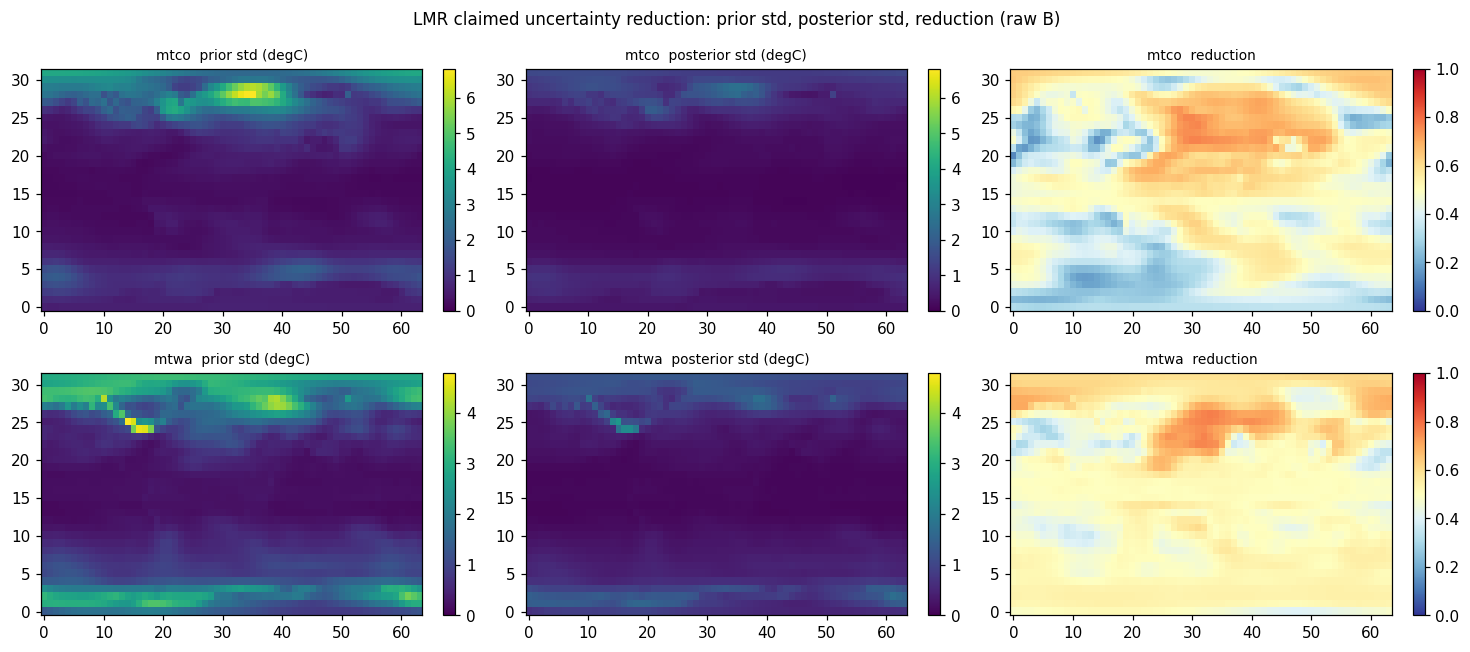

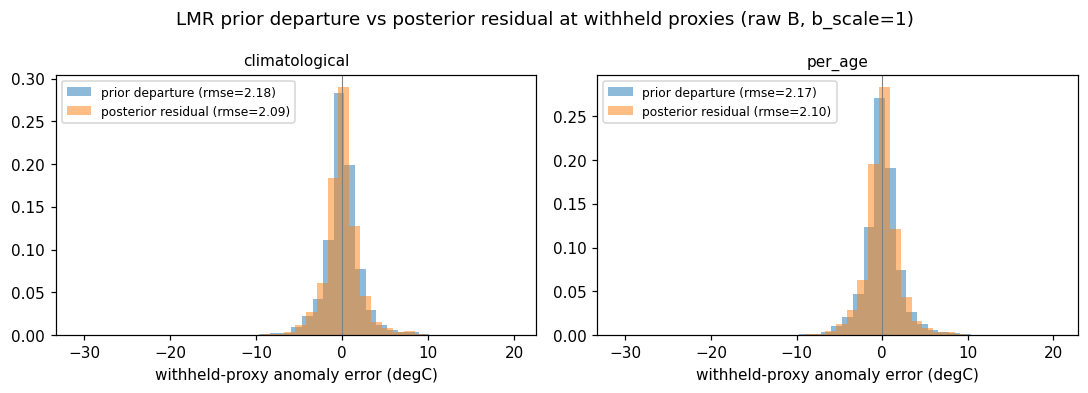

In [15]:
# Claimed uncertainty reduction over the full network (diag B vs diag A, raw B, b_scale=1).
z = np.load(OUT / "3dvar_raw" / "montecarlo_ensemble.npz")
bi1 = int(np.argmin(np.abs(z["b_scales"] - 1.0)))
da.plot_prior_posterior_uncertainty(
    z["prior_var"], z["post_var"][bi1], z["safe_valid"], VARS,
    title="LMR claimed uncertainty reduction: prior std, posterior std, reduction (raw B)",
    save_path=str(FIG / "uncertainty_reduction_montecarlo_raw.png"))
plt.show()

# Realized misfit at withheld proxies: prior departure vs posterior residual.
p = np.load(OUT / "3dvar_raw" / "montecarlo_predictions.npz")
bp = int(np.argmin(np.abs(p["b_scales"] - 1.0)))
actual = p["actual"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), squeeze=False)
for ax, bg in zip(axes[0], ("climatological", "per_age")):
    prior_pred = p[f"{bg}_prior_pred"]
    ens_mean = p[f"{bg}_ens_mean_pred"][bp]
    dep = actual - prior_pred
    res = actual - ens_mean
    rmse_prior = da.rmse(actual, prior_pred)
    rmse_post = da.rmse(actual, ens_mean)
    ax.hist(dep, bins=40, density=True, alpha=0.5, label=f"prior departure (rmse={rmse_prior:.2f})")
    ax.hist(res, bins=40, density=True, alpha=0.5, label=f"posterior residual (rmse={rmse_post:.2f})")
    ax.axvline(0, color="grey", lw=0.7)
    ax.set_title(bg, fontsize=10)
    ax.set_xlabel("withheld-proxy anomaly error (degC)")
    ax.legend(fontsize=8)
fig.suptitle("LMR prior departure vs posterior residual at withheld proxies (raw B, b_scale=1)")
fig.tight_layout()
fig.savefig(str(FIG / "montecarlo_departure_residual.png"), dpi=110, bbox_inches="tight")
plt.show()

### Ensemble calibration (proxy space)

RCRV bias and dispersion of the ensemble-mean prediction against the withheld
truth, with total predictive variance = resampling spread + posterior variance +
proxy error. Dispersion near 1 is calibrated, above 1 overconfident. A
resampling-only ensemble omits part of the predictive uncertainty, so some
over-confidence is expected and is the natural place the later EnKF improves.

metric                       rcrv_bias  rcrv_disp
B_reg        background                          
eof          climatological     -0.002      1.362
             per_age            -0.006      1.365
localization climatological     -0.002      1.322
             per_age            -0.009      1.325
raw          climatological     -0.002      1.352
             per_age            -0.005      1.355
shrinkage    climatological     -0.003      1.319
             per_age            -0.007      1.322

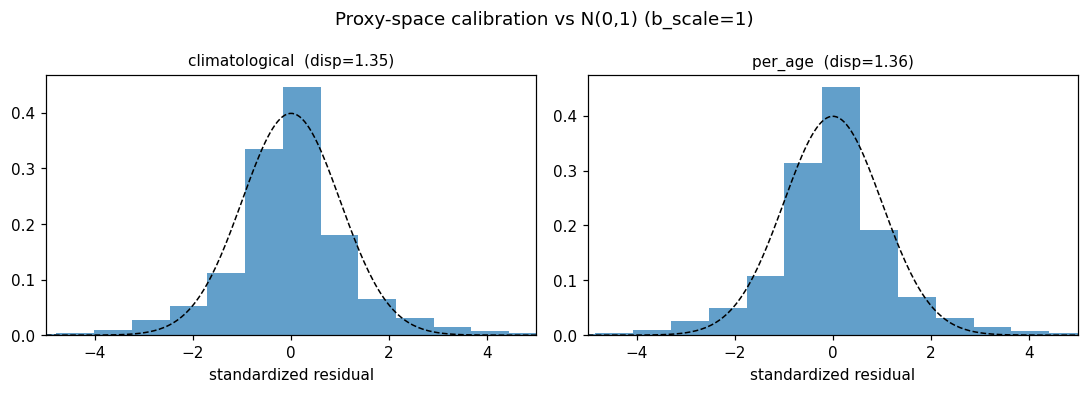

In [16]:
rc = M[(M.lane == "withholding_montecarlo") & (M.metric.isin(["rcrv_bias", "rcrv_disp"]))
       & (M.b_scale == 1.0)]
display(rc.pivot_table(index=["B_reg", "background"], columns="metric", values="value").round(3))

p = np.load(OUT / "3dvar_raw" / "montecarlo_predictions.npz")
bp = int(np.argmin(np.abs(p["b_scales"] - 1.0)))
actual = p["actual"]
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), squeeze=False)
xs = np.linspace(-5, 5, 200)
for ax, bg in zip(axes[0], ("climatological", "per_age")):
    zres = (actual - p[f"{bg}_ens_mean_pred"][bp]) / np.sqrt(p[f"{bg}_total_var"][bp])
    ax.hist(zres, bins=40, density=True, alpha=0.7)
    ax.plot(xs, np.exp(-xs ** 2 / 2) / np.sqrt(2 * np.pi), "k--", lw=1)
    ax.set_title(f"{bg}  (disp={zres.std():.2f})", fontsize=10)
    ax.set_xlim(-5, 5)
    ax.set_xlabel("standardized residual")
fig.suptitle("Proxy-space calibration vs N(0,1) (b_scale=1)")
fig.tight_layout()
fig.savefig(str(FIG / "montecarlo_calibration.png"), dpi=110, bbox_inches="tight")
plt.show()

### Reading: Monte Carlo ensemble

- The box width is the headline the k-fold number hides: skill at withheld sites
  swings with which quarter of the sparse network is held out.
- The k-fold pooled CE (red) should sit inside the Monte Carlo box; a large offset
  would flag the single k-fold split as unrepresentative.
- Resampling spread vs posterior std: the first is sensitivity to the proxy
  network, the second the analysis uncertainty for a fixed network. They do not
  measure the same thing and neither alone is the full predictive uncertainty.
- RCRV dispersion above 1 is the resampling-only ensemble underdispersed: it omits
  the proxy error and the analysis spread within a realization. Folding both into
  the predictive variance is the partial fix here; a genuine posterior ensemble is
  the EnKF's job.
- b_scale sweep: withheld-site CE peaks at the B-vs-R amplitude that best matches
  the real network; past it the analysis over-trusts the proxies and CE falls.